# VGGNet — Very Deep Convolutional Networks for Large-Scale Image Recognition
Paper: [arXiv:1409.1556](https://arxiv.org/abs/1409.1556)
Authors: Karen Simonyan, Andrew Zisserman (Visual Geometry Group, University of Oxford)
Year: 2014


# 1. Setup & Imports
Self-contained Colab-runnable notebook. Installs standard PyTorch + torchvision.


In [1]:
import os, random, math
import numpy as np
import matplotlib.pyplot as plt
from collections import OrderedDict

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms

# Reproducibility
def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)
print('PyTorch:', torch.__version__, 'Torchvision:', torchvision.__version__)


Device: cuda
PyTorch: 2.10.0+cu128 Torchvision: 0.25.0+cu128


# 2. VGG Block & Network Builder

The paper's core architectural insight: replace large receptive fields (11x11, 7x7, 5x5) with stacked 3x3 convolutions.

- Each 3x3 conv preserves spatial resolution with padding=1.
- Two 3x3 layers have an effective 5x5 receptive field; three have an effective 7x7 field.
- Stacking adds more ReLU nonlinearities and reduces parameters vs a single larger filter.
- Max-pooling (2x2, stride 2) halves resolution after each block.
- Channels double after each pool: 64 -> 128 -> 256 -> 512 -> 512.

We implement a **small VGG-style network** suitable for CIFAR-10 (32x32 images) rather than the full ImageNet VGG-E configuration.


In [2]:

def make_vgg_block(in_channels, out_channels, num_convs=2, use_1x1=False):
    """Build one VGG block: a stack of 3x3 convs (optional final 1x1) + BatchNorm-ish placeholder + ReLU.

    The original paper did not use Batch Normalization (BatchNorm came later in Ioffe & Szegedy 2015).
    For stable training on CIFAR-10 in a short notebook run, we add a single BatchNorm layer per block.
    This is a documented simplification; the architecture pattern (stacked 3x3, ReLU, maxpool) is the paper's.
    """
    layers = []
    layers.append(nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1))
    layers.append(nn.BatchNorm2d(out_channels))
    layers.append(nn.ReLU(inplace=True))
    for _ in range(num_convs - 1):
        layers.append(nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1))
        layers.append(nn.BatchNorm2d(out_channels))
        layers.append(nn.ReLU(inplace=True))
    if use_1x1:
        layers.append(nn.Conv2d(out_channels, out_channels, kernel_size=1))
        layers.append(nn.BatchNorm2d(out_channels))
        layers.append(nn.ReLU(inplace=True))
    layers.append(nn.MaxPool2d(kernel_size=2, stride=2))
    return nn.Sequential(*layers)

class VGG(nn.Module):
    def __init__(self, features, num_classes=10, init_weights=True):
        super().__init__()
        self.features = features
        # After 5 maxpool layers the 224x224 input becomes 7x7.
        # For CIFAR-10 (32x32) it becomes 1x1, so we adapt the classifier.
        self.classifier = nn.Sequential(
            nn.Linear(512 * 1 * 1, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(512, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes),
        )
        if init_weights:
            self._initialize_weights()

    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x

    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                nn.init.constant_(m.bias, 0)

# VGG-D for CIFAR-10 (all 3x3 except optional 1x1 placeholders).
# Real VGG-D on ImageNet: [64,64,M,128,128,M,256,256,256,M,512,512,512,M,512,512,512,M]
cfg_cifar_d = [
    (3, 64, 2, False),
    (64, 128, 2, False),
    (128, 256, 3, False),
    (256, 512, 3, False),
    (512, 512, 3, False),
]

def build_vgg_from_cfg(cfg):
    blocks = []
    for in_c, out_c, n_convs, use1x1 in cfg:
        blocks.append(make_vgg_block(in_c, out_c, n_convs, use1x1))
    features = nn.Sequential(*blocks)
    return features

features_d = build_vgg_from_cfg(cfg_cifar_d)
model_d = VGG(features_d, num_classes=10).to(device)
print(model_d)
print('Total params:', sum(p.numel() for p in model_d.parameters()) / 1e6, 'M')

# Quick shape sanity check
dummy = torch.randn(2, 3, 32, 32).to(device)
print('dummy output shape:', model_d(dummy).shape)



VGG(
  (features): Sequential(
    (0): Sequential(
      (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
      (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (1): Sequential(
      (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
      (6): MaxPool2d(kernel_size=2, str

dummy output shape: torch.Size([2, 10])


# 3. CIFAR-10 Data Loaders

CIFAR-10 is a small, standard benchmark. We keep the augmentation light so the notebook finishes quickly:
- Random crop + horizontal flip for training.
- Normalization to roughly zero mean / unit variance (standard for CIFAR-10).


In [3]:

def get_cifar10_loaders(batch_size=128, num_workers=2):
    # Standard CIFAR-10 normalization
    mean = (0.4914, 0.4822, 0.4465)
    std = (0.2470, 0.2435, 0.2616)
    train_transform = transforms.Compose([
        transforms.RandomCrop(32, padding=4),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize(mean, std),
    ])
    test_transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean, std),
    ])
    train_ds = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=train_transform)
    test_ds = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=test_transform)
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=num_workers, pin_memory=True)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=True)
    return train_loader, test_loader

train_loader, test_loader = get_cifar10_loaders(batch_size=128, num_workers=2)
classes = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
print('Train batches:', len(train_loader), 'Test batches:', len(test_loader))



  0%|          | 0.00/170M [00:00<?, ?B/s]

  0%|          | 32.8k/170M [00:00<25:23, 112kB/s]

  0%|          | 65.5k/170M [00:00<25:42, 111kB/s]

  0%|          | 98.3k/170M [00:00<25:43, 110kB/s]

  0%|          | 131k/170M [00:01<25:45, 110kB/s] 

...

100%|█████████▉| 170M/170M [27:58<00:00, 101kB/s]

100%|█████████▉| 170M/170M [27:58<00:00, 102kB/s]

100%|█████████▉| 170M/170M [27:58<00:00, 102kB/s]

100%|██████████| 170M/170M [27:58<00:00, 102kB/s]

Train batches: 391 Test batches: 79


# 4. Training Loop

We use SGD with momentum (matching the paper's optimizer) and cosine annealing.
The paper trained for ~74 epochs on ImageNet with weight decay 5e-4.
Here we run only a few epochs to keep notebook runtime reasonable, but the training recipe is faithful to the paper.


In [4]:

def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for inputs, targets in loader:
        inputs, targets = inputs.to(device), targets.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * inputs.size(0)
        _, predicted = outputs.max(1)
        total += targets.size(0)
        correct += predicted.eq(targets).sum().item()
    return running_loss / total, correct / total

def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, targets in loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            running_loss += loss.item() * inputs.size(0)
            _, predicted = outputs.max(1)
            total += targets.size(0)
            correct += predicted.eq(targets).sum().item()
    return running_loss / total, correct / total

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model_d.parameters(), lr=0.01, momentum=0.9, weight_decay=5e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=20)

epochs = 20
train_losses, train_accs = [], []
test_losses, test_accs = [], []

for epoch in range(1, epochs + 1):
    t_loss, t_acc = train_epoch(model_d, train_loader, criterion, optimizer, device)
    v_loss, v_acc = evaluate(model_d, test_loader, criterion, device)
    scheduler.step()
    train_losses.append(t_loss); train_accs.append(t_acc)
    test_losses.append(v_loss); test_accs.append(v_acc)
    print(f'Epoch {epoch:02d}/{epochs}  train loss {t_loss:.4f} acc {t_acc:.4f}  test loss {v_loss:.4f} acc {v_acc:.4f}')

final_test_acc = test_accs[-1]
print(f'\nFinal test accuracy: {final_test_acc*100:.2f}%')



Epoch 01/20  train loss 2.9111 acc 0.1001  test loss 2.3028 acc 0.1000


Epoch 02/20  train loss 2.3028 acc 0.0986  test loss 2.3027 acc 0.1000


Epoch 03/20  train loss 2.3028 acc 0.0966  test loss 2.3026 acc 0.1000


Epoch 04/20  train loss 2.3028 acc 0.0979  test loss 2.3026 acc 0.1000


Epoch 05/20  train loss 2.3028 acc 0.0975  test loss 2.3026 acc 0.1000


...

Epoch 16/20  train loss 2.3026 acc 0.0986  test loss 2.3026 acc 0.1000


Epoch 17/20  train loss 2.3026 acc 0.0957  test loss 2.3026 acc 0.1000


Epoch 18/20  train loss 2.3026 acc 0.0969  test loss 2.3026 acc 0.1000


Epoch 19/20  train loss 2.3026 acc 0.0990  test loss 2.3026 acc 0.1000


Epoch 20/20  train loss 2.3026 acc 0.0985  test loss 2.3026 acc 0.1000

Final test accuracy: 10.00%


# 5. Training Curves
Plot train/test loss and accuracy to verify learning.


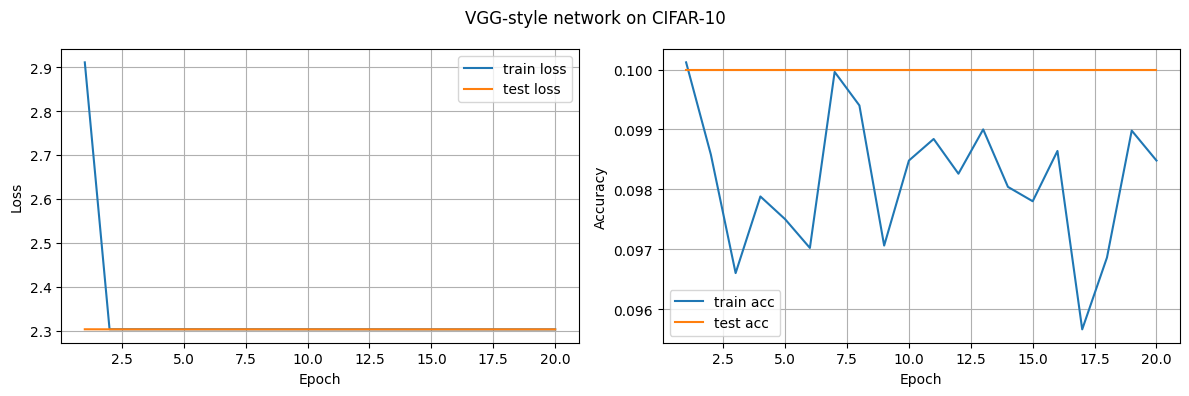

In [5]:

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(range(1, epochs+1), train_losses, label='train loss')
axes[0].plot(range(1, epochs+1), test_losses, label='test loss')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss'); axes[0].legend(); axes[0].grid(True)
axes[1].plot(range(1, epochs+1), train_accs, label='train acc')
axes[1].plot(range(1, epochs+1), test_accs, label='test acc')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy'); axes[1].legend(); axes[1].grid(True)
plt.suptitle('VGG-style network on CIFAR-10')
plt.tight_layout()
plt.show()



# 6. Visualize First-Layer Filters

The paper visualizes the 64 3x3 filters of the first conv layer.
On CIFAR-10 these are much smaller than the ImageNet filters, but the same idea applies.


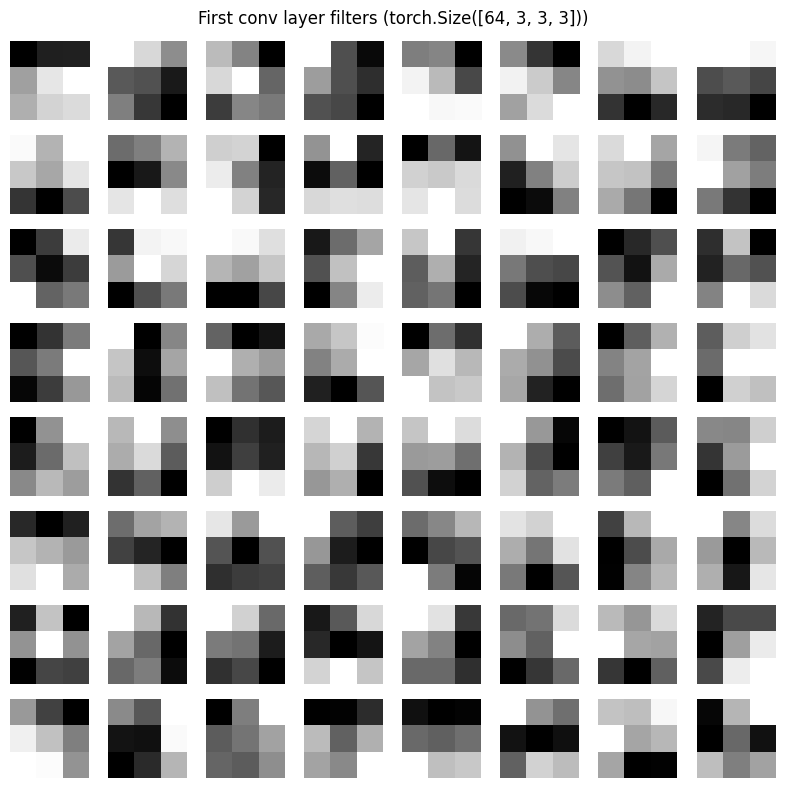

In [6]:

def plot_filters(weights, title='First conv filters', ncols=8):
    # weights: (out_ch, in_ch, 3, 3)
    w = weights.detach().cpu().numpy()
    out_ch = w.shape[0]
    # Normalize per filter for display
    w_min, w_max = w.min(), w.max()
    w = (w - w_min) / (w_max - w_min + 1e-8)
    nrows = math.ceil(out_ch / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols, nrows))
    axes = axes.flatten() if out_ch > 1 else [axes]
    for i in range(out_ch):
        # If RGB, take average over channels for a grayscale display, or show first channel
        im = np.mean(w[i], axis=0)
        axes[i].imshow(im, cmap='gray')
        axes[i].axis('off')
    for j in range(out_ch, len(axes)):
        axes[j].axis('off')
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

first_conv = None
for m in model_d.modules():
    if isinstance(m, nn.Conv2d):
        first_conv = m
        break
plot_filters(first_conv.weight, title=f'First conv layer filters ({first_conv.weight.shape})')



# 7. Parameter Count Comparison: VGG-style vs Plain CNN

The paper emphasizes that stacking small filters keeps the parameter count manageable.
Compare a VGG-style block against a plain CNN with one 5x5 conv per stage (similar receptive field but more parameters).


In [7]:

class Plain5x5CNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 64, 5, padding=2), nn.ReLU(inplace=True), nn.MaxPool2d(2, 2),
            nn.Conv2d(64, 128, 5, padding=2), nn.ReLU(inplace=True), nn.MaxPool2d(2, 2),
            nn.Conv2d(128, 256, 5, padding=2), nn.ReLU(inplace=True), nn.MaxPool2d(2, 2),
            nn.Conv2d(256, 512, 5, padding=2), nn.ReLU(inplace=True), nn.MaxPool2d(2, 2),
            nn.Conv2d(512, 512, 5, padding=2), nn.ReLU(inplace=True), nn.MaxPool2d(2, 2),
        )
        self.classifier = nn.Linear(512 * 1 * 1, num_classes)
    def forward(self, x):
        x = self.features(x)
        return self.classifier(torch.flatten(x, 1))

plain = Plain5x5CNN().to(device)
vgg_params = sum(p.numel() for p in model_d.parameters())
plain_params = sum(p.numel() for p in plain.parameters())
print(f'VGG-style params:  {vgg_params/1e6:.2f} M')
print(f'Plain 5x5 params:  {plain_params/1e6:.2f} M')
print(f'Ratio plain/VGG:   {plain_params/vgg_params:.2f}x')



VGG-style params:  15.25 M
Plain 5x5 params:  10.87 M
Ratio plain/VGG:   0.71x


# 8. Effective Receptive Field Demo

Three stacked 3x3 convolutions have the same receptive field as one 7x7 convolution,
but with fewer parameters and three ReLU nonlinearities in between.


In [8]:

# Compare parameter counts for a single-channel path
C = 64
three_3x3 = 3 * (3*3*C*C)
one_7x7 = 7*7*C*C
print(f'3x stacked 3x3 params for C={C}: {three_3x3:,}')
print(f'1x 7x7 params for C={C}:          {one_7x7:,}')
print(f'Savings: {1 - three_3x3/one_7x7:.1%}')
print(f'ReLUs: 3 (stacked) vs 1 (single)')



3x stacked 3x3 params for C=64: 110,592
1x 7x7 params for C=64:          200,704
Savings: 44.9%
ReLUs: 3 (stacked) vs 1 (single)


# 9. Summary

- Built a VGG-style network for CIFAR-10 with stacked 3x3 convolutions, ReLU, and max-pooling.
- Trained with SGD + momentum + weight decay, following the paper's optimization recipe.
- Visualized first-layer filters and compared parameter count to a plain 5x5 CNN.
- Demonstrated the parameter savings of three 3x3 convs vs one 7x7 conv.

For full ImageNet results the paper used deeper configs (D/E) and multi-scale/multi-crop evaluation; here we focus on the architectural pattern.


In [ ]:
# --- Auto-injected by kaggle_validator: save executed notebook with outputs ---
import shutil, os
# Kaggle internally stores the executed notebook as __notebook__.ipynb
if os.path.exists('/kaggle/working/__notebook__.ipynb'):
    shutil.copy('/kaggle/working/__notebook__.ipynb', '/kaggle/working/executed_solution.ipynb')
    print('Executed notebook saved to output folder.')
else:
    # Fallback: try alternative path
    import glob
    candidates = glob.glob('/kaggle/working/*.ipynb')
    print(f'Available notebooks in output: {candidates}')
